# Excel EDA / Analyse exploratoire Excel - Polypbase

**Date :** 2026-05-05

**FR - Objectif :** Ce notebook analyse les anciens fichiers Excel de suivi des polypes. Il sert à comprendre la structure des fichiers, transformer les tableaux en données exploitables, puis produire des premiers résultats lisibles.

**EN - Goal:** This notebook analyzes the historical Excel files used to track polyp cultures. It helps understand the file structure, reshape the spreadsheets into usable data, and produce first readable results.

**FR - Point de prudence :** les résultats décrivent les données disponibles. Ils ne prouvent pas encore une relation biologique. Une cellule vide n'est pas transformée en zéro, car elle peut correspondre à une absence de suivi, une boîte inactive, une période avant/après changement de température, ou un repiquage.

**EN - Caution:** the results describe the available data. They do not prove a biological relationship yet. Empty cells are not converted to zero because they may mean missing tracking, an inactive box, a period before/after a temperature change, or a repiquage event.


## 1. Préparation du notebook / Notebook setup

**FR -** Cette partie charge les bibliothèques utiles et définit les chemins vers les fichiers Excel locaux. Les données réelles doivent rester hors du dépôt Git.

**EN -** This section imports the required libraries and defines paths to the local Excel files. Real data must stay outside the Git repository.


In [1]:
#install matplotlib
#uv add matplotlib
from pathlib import Path
import re
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 80)

# Folder containing the local Excel files.
# Keep real Aquarium data outside Git and update this path if needed.
DATA_DIR = Path("../data")

# Yearly tracking files: Suivi_2019.xlsx, Suivi_2020.xlsx, and so on.
TRACKING_FILES = sorted(DATA_DIR.glob("Suivi_*.xlsx"))
# Exclure Suivi_2019.xlsx
TRACKING_FILES = [f for f in TRACKING_FILES if "2019" not in f.name]
# Additional files explored near the end of the notebook.
CHANGES_FILE = DATA_DIR / "ChangementT°C_Repiquage.xlsx"
STROBILATION_FILE = DATA_DIR / "SuiviStrobilation.xlsx"

# The source files may use accented or unaccented spellings.
TRACKED_MEASUREMENT_PATTERN = r"polype|ephyr|éphyr"
EPHYRAE_PATTERN = r"ephyr|éphyr"

print("Tracking files found:")
for file in TRACKING_FILES:
    print("-", file.name)

if not TRACKING_FILES:
    print("No Suivi_*.xlsx file found. Check the DATA_DIR folder.")

Tracking files found:
- Suivi_2020.xlsx
- Suivi_2021.xlsx
- Suivi_2022.xlsx
- Suivi_2023.xlsx
- Suivi_2024.xlsx
- Suivi_2025.xlsx
- Suivi_2026.xlsx


## 2. Vérification des feuilles disponibles / Available sheets check

**FR -** On liste les feuilles présentes dans chaque fichier annuel pour repérer les structures utiles et les feuilles temporaires.

**EN -** We list the sheets in each yearly file to identify useful structures and temporary sheets.


In [2]:
sheets_by_file = []

for file in TRACKING_FILES:
    try:
        workbook = pd.ExcelFile(file)
        sheets_by_file.append({
            "file": file.name,
            "sheet_count": len(workbook.sheet_names),
            "sheets": ", ".join(workbook.sheet_names)
        })
    except Exception as error:
        sheets_by_file.append({
            "file": file.name,
            "sheet_count": np.nan,
            "sheets": f"ERROR: {error}"
        })

sheets_summary = pd.DataFrame(sheets_by_file)
display(sheets_summary)

# Automatic note about the result.
if not sheets_summary.empty:
    all_sheets = []
    for text in sheets_summary["sheets"]:
        all_sheets.extend([sheet.strip() for sheet in str(text).split(",")])
    unique_sheets = sorted(set(all_sheets))
    temporary_sheets = [sheet for sheet in unique_sheets if sheet.lower().startswith("feuil")]

    print("Comment:")
    print(f"The files contain {len(unique_sheets)} different sheet names in total.")
    if temporary_sheets:
        print("Some sheets look temporary or less reliable for automatic processing:", temporary_sheets)
    if "Rhizostomae" in unique_sheets and "Rhizostomeae" in unique_sheets:
        print("There is also a spelling variation between 'Rhizostomae' and 'Rhizostomeae'. This name will probably need normalization later.")
    print("Overall, the files seem organized by broad groups, which makes a first grouped analysis possible.")


,file,sheet_count,sheets
0,Suivi_2020.xlsx,6,"Aurelia, Cubozoa, Hydrozoa, Rhizostomae, Semae..."
1,Suivi_2021.xlsx,6,"Aurelia, Cubozoa, Hydrozoa, Rhizostomae, Semae..."
2,Suivi_2022.xlsx,6,"Aurelia, Cubozoa, Hydrozoa, Rhizostomae, Semae..."
3,Suivi_2023.xlsx,7,"Aurelia, Hydrozoa, Cubozoa, Rhizostomeae, Sema..."
4,Suivi_2024.xlsx,9,"Aurelia, Hydrozoa, Cubozoa, Rhizostomae, Semae..."
5,Suivi_2025.xlsx,9,"Aurelia, Hydrozoa, Cubozoa, Rhizostomae, Feuil..."
6,Suivi_2026.xlsx,7,"Aurelia, Hydrozoa, Cubozoa, Rhizostomae, Feuil..."


Comment:
The files contain 11 different sheet names in total.
Some sheets look temporary or less reliable for automatic processing: ['Feuil1', 'Feuil2']
There is also a spelling variation between 'Rhizostomae' and 'Rhizostomeae'. This name will probably need normalization later.
Overall, the files seem organized by broad groups, which makes a first grouped analysis possible.


## 3. Aperçu brut d'une feuille Excel / Raw Excel sheet preview

**FR -** Cette lecture brute permet de voir comment les tableaux sont organisés avant nettoyage : lignes de contexte, colonnes de mesure et colonnes de semaines.

**EN -** This raw preview shows how the sheets are organized before cleaning: context rows, measurement columns, and week columns.


In [3]:
# Editable example: change the file or sheet name if needed.
example_file = DATA_DIR / "Suivi_2026.xlsx"
example_sheet = "Aurelia"

if example_file.exists():
    raw_preview = pd.read_excel(example_file, sheet_name=example_sheet, header=None)
    print("Displayed file:", example_file.name)
    print("Displayed sheet:", example_sheet)
    display(raw_preview.iloc[:15, :22])

    print("Comment:")
    print("The table contains species, box numbers, temperatures, and two measurement types: polyps and ephyrae.")
    print("Values are then spread by week. Empty cells must not automatically be treated as zeroes.")
    print("In some files, the header row may contain a year that was not updated. For this analysis, the year comes from the file name.")
else:
    print("Example file not found:", example_file)


Displayed file: Suivi_2026.xlsx
Displayed sheet: Aurelia


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21
0,,NaN,NaN,NaN,2025.0,JANVIER,NaN,NaN,NaN,NaN,FEVRIER,NaN,NaN,NaN,MARS,NaN,NaN,NaN,AVRIL,NaN,NaN,NaN
1,Espèce,N° boîte,Température (°C),NaN,NaN,1,2.0,3.0,4.0,5.0,6,7.0,8.0,9.0,10,11.0,12.0,13.0,14,15.0,16.0,17.0
2,Aurelia aurita,AAU-NBE-1.01,10,Nb polypes,80.0,80,80.0,80.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,Nb éphyrules,0.0,0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,15,Nb polypes,NaN,NaN,NaN,NaN,80.0,80.0,100,100.0,100.0,100.0,100,120.0,120.0,150.0,150,170.0,170.0,170.0
5,NaN,NaN,NaN,Nb éphyrules,NaN,NaN,NaN,NaN,0.0,1.0,0,0.0,0.0,0.0,0,0.0,0.0,0.0,0,0.0,0.0,0.0
6,NaN,AAU-NBE-1.02,10,Nb polypes,NaN,NaN,NaN,NaN,70.0,100.0,100,100.0,100.0,100.0,120,120.0,120.0,150.0,150,150.0,150.0,150.0
7,NaN,NaN,NaN,Nb éphyrules,NaN,NaN,NaN,NaN,0.0,0.0,0,0.0,0.0,0.0,0,8.0,150.0,200.0,150,100.0,10.0,5.0
8,NaN,NaN,15,Nb polypes,60.0,70,70.0,70.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,Nb éphyrules,0.0,0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Comment:
The table contains species, box numbers, temperatures, and two measurement types: polyps and ephyrae.
Values are then spread by week. Empty cells must not automatically be treated as zeroes.
In some files, the header row may contain a year that was not updated. For this analysis, the year comes from the file name.


## 4. Nettoyage et transformation des données / Data cleaning and reshaping

**FR -** Les tableaux Excel sont transformés en format long : une ligne correspond à une boîte, une mesure et une semaine. Ce format sera plus simple à stocker dans PostgreSQL et à afficher dans la webapp.

**EN -** The Excel tables are reshaped into long format: one row represents one box, one measurement, and one week. This format will be easier to store in PostgreSQL and display in the webapp.


In [4]:
def extract_year_from_filename(file: Path):
    """Extract the year from a file name such as Suivi_2026.xlsx."""
    match = re.search(r"(20\d{2})", file.name)
    return int(match.group(1)) if match else None


def clean_tracking_sheet(file: Path, sheet_name: str):
    """Clean one yearly tracking sheet.

    Expected result: one row = one value for one box, one week, and one measurement type.
    Empty cells stay empty: they are not replaced by zero.
    """
    raw = pd.read_excel(file, sheet_name=sheet_name, header=None)
    if raw.empty or raw.shape[0] < 3 or raw.shape[1] < 5:
        return pd.DataFrame()

    file_year = extract_year_from_filename(file)

    # The first two rows usually contain months and week numbers.
    data = raw.iloc[2:].copy()

    # The first four columns describe the measurement row.
    data = data.rename(columns={
        0: "species",
        1: "box",
        2: "temperature",
        3: "measurement_type"
    })

    # In Excel, empty cells often reuse information from the row above.
    # We therefore forward-fill species, box, and temperature.
    for column in ["species", "box", "temperature"]:
        data[column] = data[column].ffill()

    # Apply light text cleanup.
    for column in ["species", "box", "measurement_type"]:
        data[column] = data[column].astype("string").str.strip()

    # Keep only rows that match the biological measurements tracked in the files.
    data = data[data["measurement_type"].notna()]
    data = data[data["measurement_type"].str.contains(TRACKED_MEASUREMENT_PATTERN, case=False, na=False)]

    # Columns starting at column E correspond to weeks.
    value_columns = [column for column in data.columns if isinstance(column, int) and column >= 4]
    value_columns = value_columns[:52]  # Keep a maximum of 52 weeks.

    if not value_columns:
        return pd.DataFrame()

    # Simple mapping: first value column = week 1, second = week 2, and so on.
    week_mapping = {
        column: {"week_index": index, "excel_column": column + 1}
        for index, column in enumerate(value_columns, start=1)
    }

    long_df = data.melt(
        id_vars=["species", "box", "temperature", "measurement_type"],
        value_vars=value_columns,
        var_name="source_column",
        value_name="value"
    )

    long_df["file_year"] = file_year
    long_df["group"] = sheet_name
    long_df["week_index"] = long_df["source_column"].map(lambda column: week_mapping[column]["week_index"])
    long_df["excel_column"] = long_df["source_column"].map(lambda column: week_mapping[column]["excel_column"])

    long_df["temperature"] = pd.to_numeric(long_df["temperature"], errors="coerce")
    long_df["value"] = pd.to_numeric(long_df["value"], errors="coerce")

    long_df["normalized_measurement_type"] = np.where(
        long_df["measurement_type"].str.contains(EPHYRAE_PATTERN, case=False, na=False),
        "ephyrae",
        "polyps"
    )

    columns = [
        "file_year", "group", "species", "box", "temperature",
        "measurement_type", "normalized_measurement_type", "week_index",
        "excel_column", "value"
    ]
    return long_df[columns]


def load_all_tracking_files(files):
    """Load all tracking files and merge usable sheets."""
    chunks = []
    errors = []

    for file in files:
        try:
            workbook = pd.ExcelFile(file)
        except Exception as error:
            errors.append((file.name, None, str(error)))
            continue

        for sheet in workbook.sheet_names:
            # Sheets named Feuil1, Feuil2, and so on are ignored because they are often temporary.
            if sheet.lower().startswith("feuil"):
                continue
            try:
                sheet_df = clean_tracking_sheet(file, sheet)
                if not sheet_df.empty:
                    chunks.append(sheet_df)
            except Exception as error:
                errors.append((file.name, sheet, str(error)))

    tracking_df = pd.concat(chunks, ignore_index=True) if chunks else pd.DataFrame()
    return tracking_df, errors


## 5. Chargement de tous les fichiers / Loading all yearly files

**FR -** On applique le même nettoyage à tous les fichiers de suivi disponibles afin d'obtenir une table unique.

**EN -** We apply the same cleaning process to all available tracking files to build one consolidated table.


In [5]:
tracking_df, errors = load_all_tracking_files(TRACKING_FILES)

print("Rows in the cleaned table:", len(tracking_df))
print("Files or sheets with errors:", len(errors))

if errors:
    print("Errors to check:")
    for error in errors[:20]:
        print(error)

display(tracking_df.head(20))

print("Comment:")
if tracking_df.empty:
    print("No data was loaded. Check the folder path and file names.")
else:
    print("The files were merged into one table. Each row represents one possible measurement for one box and one week.")
    print("The row count is high because the long format creates one row for each week, even when the original cell was empty.")
    if not errors:
        print("No technical error was found during loading.")


Rows in the cleaned table: 238576
Files or sheets with errors: 0


,file_year,group,species,box,temperature,measurement_type,normalized_measurement_type,week_index,excel_column,value
0,2020,Aurelia,Aurelia labiata,ALA-JKA-1.02,5.0,Nb polypes,polyps,1,5,200.0
1,2020,Aurelia,Aurelia labiata,ALA-JKA-1.02,5.0,Nb éphyrules,ephyrae,1,5,200.0
2,2020,Aurelia,Aurelia labiata,ALA-JKA-1.02,15.0,Nb polypes,polyps,1,5,NaN
3,2020,Aurelia,Aurelia labiata,ALA-JKA-1.02,15.0,Nb éphyrules,ephyrae,1,5,NaN
4,2020,Aurelia,Aurelia labiata,ALA-JKA-1.03,5.0,Nb polypes,polyps,1,5,NaN
5,2020,Aurelia,Aurelia labiata,ALA-JKA-1.03,5.0,Nb éphyrules,ephyrae,1,5,NaN
6,2020,Aurelia,Aurelia labiata,ALA-JKA-1.03,15.0,Nb polypes,polyps,1,5,50.0
7,2020,Aurelia,Aurelia labiata,ALA-JKA-1.03,15.0,Nb éphyrules,ephyrae,1,5,0.0
8,2020,Aurelia,Aurelia labiata,ALA-JKA-1.04,5.0,Nb polypes,polyps,1,5,NaN
9,2020,Aurelia,Aurelia labiata,ALA-JKA-1.04,5.0,Nb éphyrules,ephyrae,1,5,NaN


Comment:
The files were merged into one table. Each row represents one possible measurement for one box and one week.
The row count is high because the long format creates one row for each week, even when the original cell was empty.
No technical error was found during loading.


## 6. Contrôle qualité général / General quality check

**FR -** Ces contrôles donnent une première idée de la qualité des données : nombre de lignes, valeurs manquantes, années disponibles et types de mesures.

**EN -** These checks give a first view of data quality: row count, missing values, available years, and measurement types.


In [6]:
if not tracking_df.empty:
    quality_indicators = pd.DataFrame({
        "indicator": [
            "Available years",
            "Group count",
            "Species count",
            "Box count",
            "Different temperatures",
            "Total rows",
            "Rows with numeric value"
        ],
        "value": [
            ", ".join(map(str, sorted(tracking_df["file_year"].dropna().unique()))),
            tracking_df["group"].nunique(),
            tracking_df["species"].nunique(),
            tracking_df["box"].nunique(),
            ", ".join(map(str, sorted(tracking_df["temperature"].dropna().unique()))),
            len(tracking_df),
            tracking_df["value"].notna().sum()
        ]
    })

    display(quality_indicators)

    missing_summary = (
        tracking_df.isna().mean()
        .sort_values(ascending=False)
        .mul(100)
        .round(1)
        .to_frame("missing_value_rate_%")
    )
    display(missing_summary)

    empty_value_rate = tracking_df["value"].isna().mean() * 100

    print("Comment:")
    print(f"The table contains {tracking_df['species'].nunique()} species and {tracking_df['box'].nunique()} different boxes.")
    print(f"About {empty_value_rate:.1f}% of rows have no numeric value.")
    print("These empty cells are not replaced by zero because they may mean missing tracking, an inactive box, a condition change, or possibly a subculture event.")
    print("The difference between 'empty' and 'zero' is essential: zero means an observation was made, while an empty cell means we cannot directly conclude.")
else:
    print("No data to check.")


,indicator,value
0,Available years,"2020, 2021, 2022, 2023, 2024, 2025, 2026"
1,Group count,8
2,Species count,147
3,Box count,575
4,Different temperatures,"5.0, 10.0, 15.0, 20.0, 25.0, 30.0"
5,Total rows,238576
6,Rows with numeric value,77686


,missing_value_rate_%
value,67.4
temperature,0.3
group,0.0
file_year,0.0
box,0.0
species,0.0
measurement_type,0.0
normalized_measurement_type,0.0
week_index,0.0
excel_column,0.0


Comment:
The table contains 147 species and 575 different boxes.
About 67.4% of rows have no numeric value.
These empty cells are not replaced by zero because they may mean missing tracking, an inactive box, a condition change, or possibly a subculture event.
The difference between 'empty' and 'zero' is essential: zero means an observation was made, while an empty cell means we cannot directly conclude.


## 7. Table des valeurs saisies / Table of entered values

**FR -** Cette table affiche uniquement les valeurs réellement saisies après nettoyage. Elle aide à contrôler rapidement si la transformation garde les informations importantes.

**EN -** This table shows only the values that were actually entered after cleaning. It helps quickly check whether the reshaping keeps the important information.


In [7]:
entered_values_df = tracking_df[tracking_df["value"].notna()].copy() if not tracking_df.empty else pd.DataFrame()

print("Rows with a real numeric value:", len(entered_values_df))
display(entered_values_df.head(20))

print("Comment:")
if entered_values_df.empty:
    print("No usable numeric value was found.")
else:
    print("This table is better for calculations because it only keeps measurements that were actually entered.")
    print("Zeroes are kept: for example, 0 ephyrae is useful information and differs from an empty cell.")


Rows with a real numeric value: 77686


,file_year,group,species,box,temperature,measurement_type,normalized_measurement_type,week_index,excel_column,value
0,2020,Aurelia,Aurelia labiata,ALA-JKA-1.02,5.0,Nb polypes,polyps,1,5,200.0
1,2020,Aurelia,Aurelia labiata,ALA-JKA-1.02,5.0,Nb éphyrules,ephyrae,1,5,200.0
6,2020,Aurelia,Aurelia labiata,ALA-JKA-1.03,15.0,Nb polypes,polyps,1,5,50.0
7,2020,Aurelia,Aurelia labiata,ALA-JKA-1.03,15.0,Nb éphyrules,ephyrae,1,5,0.0
14,2020,Aurelia,Aurelia limbata,ALI-JKA-1.03,10.0,Nb polypes,polyps,1,5,200.0
15,2020,Aurelia,Aurelia limbata,ALI-JKA-1.03,10.0,Nb éphyrules,ephyrae,1,5,0.0
22,2020,Aurelia,Aurelia limbata,ALI-JKA-2.02,10.0,Nb polypes,polyps,1,5,100.0
23,2020,Aurelia,Aurelia limbata,ALI-JKA-2.02,10.0,Nb éphyrules,ephyrae,1,5,0.0
24,2020,Aurelia,Aurelia limbata,ALI-FPA-3.01,5.0,Nb polypes,polyps,1,5,200.0
25,2020,Aurelia,Aurelia limbata,ALI-FPA-3.01,5.0,Nb éphyrules,ephyrae,1,5,200.0


Comment:
This table is better for calculations because it only keeps measurements that were actually entered.
Zeroes are kept: for example, 0 ephyrae is useful information and differs from an empty cell.


## 8. Résumé par année / Summary by year

**FR -** Cette synthèse montre les volumes de données disponibles par année. Elle sert surtout à repérer les années bien renseignées et les années plus fragiles.

**EN -** This summary shows the amount of data available per year. It mainly helps identify well-documented years and weaker years.


,file_year,normalized_measurement_type,total,average,median,value_count,box_count,species_count
0,2020,ephyrae,122343.0,28.320139,0.0,4320,123,52
1,2020,polyps,465916.0,107.875897,100.0,4319,123,52
2,2021,ephyrae,101082.0,19.155202,0.0,5277,142,51
3,2021,polyps,531455.0,101.133206,100.0,5255,142,51
4,2022,ephyrae,63190.0,13.045004,0.0,4844,192,56
5,2022,polyps,387494.0,79.994633,50.0,4844,192,56
6,2023,ephyrae,75801.0,13.480526,0.0,5623,170,60
7,2023,polyps,599078.0,104.478200,70.0,5734,172,60
8,2024,ephyrae,117017.0,17.988778,0.0,6505,192,81
9,2024,polyps,763129.0,115.678187,70.0,6597,193,81


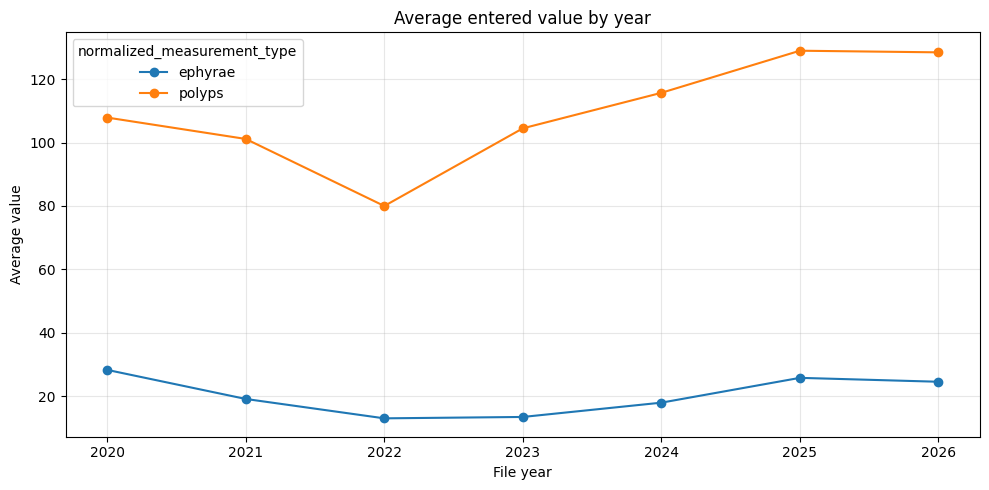

Comment:
The highest entered ephyrae total is in 2025, with 210126 cumulative ephyrae.
The highest entered polyp total is in 2025, with 1049547 cumulative polyps.
These results describe entered data only. They are not enough to conclude that one year is biologically better, because the number of tracked boxes and weeks changes by year.


In [8]:
if not entered_values_df.empty:
    yearly_summary = (
        entered_values_df
        .groupby(["file_year", "normalized_measurement_type"])
        .agg(
            total=("value", "sum"),
            average=("value", "mean"),
            median=("value", "median"),
            value_count=("value", "count"),
            box_count=("box", "nunique"),
            species_count=("species", "nunique")
        )
        .reset_index()
    )

    display(yearly_summary)

    # Simple chart of yearly averages.
    plot_df = yearly_summary.pivot(index="file_year", columns="normalized_measurement_type", values="average")
    ax = plot_df.plot(kind="line", marker="o", figsize=(10, 5))
    ax.set_title("Average entered value by year")
    ax.set_xlabel("File year")
    ax.set_ylabel("Average value")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print("Comment:")
    max_ephyrae_year = yearly_summary[yearly_summary["normalized_measurement_type"] == "ephyrae"].sort_values("total", ascending=False).head(1)
    max_polyps_year = yearly_summary[yearly_summary["normalized_measurement_type"] == "polyps"].sort_values("total", ascending=False).head(1)
    if not max_ephyrae_year.empty:
        print(f"The highest entered ephyrae total is in {int(max_ephyrae_year.iloc[0]['file_year'])}, with {max_ephyrae_year.iloc[0]['total']:.0f} cumulative ephyrae.")
    if not max_polyps_year.empty:
        print(f"The highest entered polyp total is in {int(max_polyps_year.iloc[0]['file_year'])}, with {max_polyps_year.iloc[0]['total']:.0f} cumulative polyps.")
    print("These results describe entered data only. They are not enough to conclude that one year is biologically better, because the number of tracked boxes and weeks changes by year.")
else:
    print("No numeric values available for the yearly summary.")


## 9. Résumé par espèce / Summary by species

**FR -** Cette vue compare les espèces présentes dans les fichiers. Elle peut aider à préparer les filtres de consultation de Polypbase.

**EN -** This view compares the species found in the files. It can help prepare the consultation filters in Polypbase.


,species,normalized_measurement_type,total,average,value_count,box_count,years
256,Stomolophus sp.2,ephyrae,46617.0,124.644385,374,8,4
72,Cephea cephea,ephyrae,46294.0,71.773643,645,7,7
112,Clytia hemisphaerica,ephyrae,43152.0,116.312668,371,8,5
66,Catostylus mosaicus,ephyrae,39509.0,56.200569,703,9,7
154,Eirene lacteoides,ephyrae,38732.0,60.236392,643,9,7
180,Leuckartiara sp.,ephyrae,37829.0,59.015601,641,10,7
194,Lychnorhiza lucerna,ephyrae,35110.0,54.518634,644,5,7
122,Cotylorhiza tuberculata,ephyrae,24083.0,34.015537,708,15,7
252,Stomolophus meleagris,ephyrae,22310.0,58.556430,381,11,6
30,Aurelia limbata,ephyrae,21984.0,29.950954,734,10,7


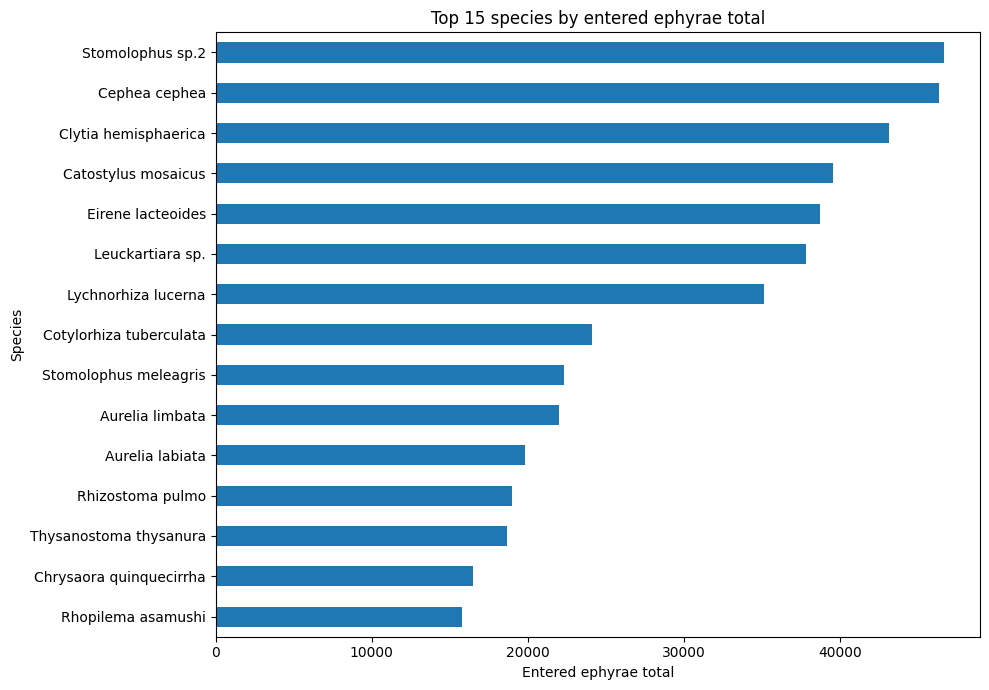

Comment:
In the cleaned data, the species with the highest entered ephyrae total is Stomolophus sp.2, with 46617 cumulative ephyrae.
This total must be compared with the number of boxes, years, and available values, because a heavily tracked species is more likely to have a high total.
This ranking is mainly useful to identify important species that deserve a deeper analysis.


In [9]:
if not entered_values_df.empty:
    species_summary = (
        entered_values_df
        .groupby(["species", "normalized_measurement_type"])
        .agg(
            total=("value", "sum"),
            average=("value", "mean"),
            value_count=("value", "count"),
            box_count=("box", "nunique"),
            years=("file_year", "nunique")
        )
        .reset_index()
    )

    top_ephyrae = (
        species_summary[species_summary["normalized_measurement_type"] == "ephyrae"]
        .sort_values("total", ascending=False)
        .head(15)
    )

    display(top_ephyrae)

    ax = top_ephyrae.sort_values("total").plot(
        kind="barh", x="species", y="total", figsize=(10, 7), legend=False
    )
    ax.set_title("Top 15 species by entered ephyrae total")
    ax.set_xlabel("Entered ephyrae total")
    ax.set_ylabel("Species")
    plt.tight_layout()
    plt.show()

    print("Comment:")
    if not top_ephyrae.empty:
        top_row = top_ephyrae.iloc[0]
        print(f"In the cleaned data, the species with the highest entered ephyrae total is {top_row['species']}, with {top_row['total']:.0f} cumulative ephyrae.")
        print("This total must be compared with the number of boxes, years, and available values, because a heavily tracked species is more likely to have a high total.")
        print("This ranking is mainly useful to identify important species that deserve a deeper analysis.")
else:
    print("No numeric values available for the species summary.")


## 10. Résumé par température / Summary by temperature

**FR -** Cette partie observe les données selon la température indiquée dans Excel. Il faudra confirmer avec l'Aquarium si cette température correspond toujours à une zone thermique ou à une valeur mesurée.

**EN -** This section reviews the data using the temperature written in Excel. We still need to confirm with the Aquarium whether this temperature always means a thermal zone or a measured value.


,temperature,normalized_measurement_type,total,average,median,value_count,box_count,species_count
0,5.0,ephyrae,52247.0,25.449099,0.0,2053,45,11
2,10.0,ephyrae,72482.0,13.650094,0.0,5310,121,41
4,15.0,ephyrae,185832.0,20.912897,0.0,8886,194,54
6,20.0,ephyrae,158137.0,16.204222,0.0,9759,220,53
8,25.0,ephyrae,223457.0,24.889396,0.0,8978,236,73
10,30.0,ephyrae,94281.0,26.066077,0.0,3617,89,30
1,5.0,polyps,301583.0,146.970273,150.0,2052,45,11
3,10.0,polyps,513691.0,97.161150,70.0,5287,121,41
5,15.0,polyps,738596.0,83.874177,50.0,8806,194,54
7,20.0,polyps,1032302.0,104.251868,80.0,9902,222,53


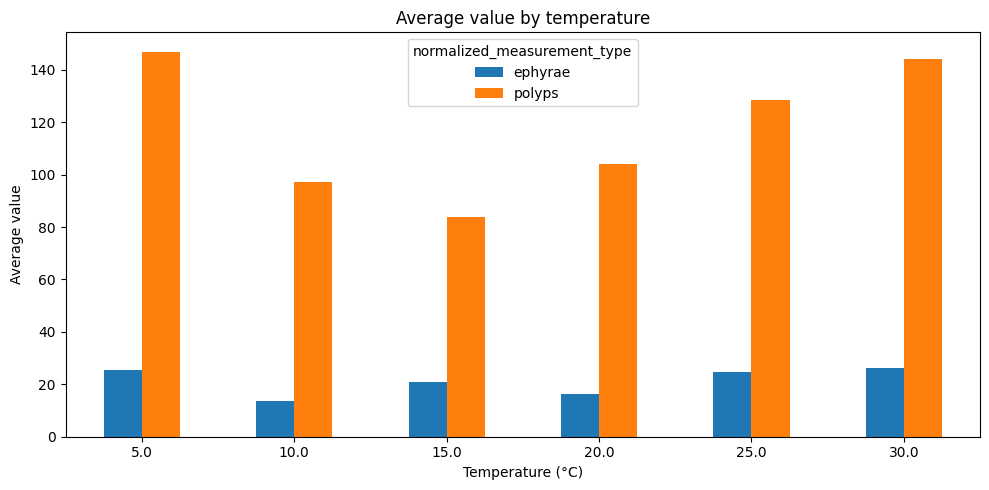

Comment:
The highest average ephyrae value appears at 30 °C in the available data.
This result must be interpreted carefully: it may depend on the species present at each temperature, the number of tracked boxes, and condition changes during the year.
To go further, temperatures should be compared within the same species and with subculture or temperature-change events included.


In [10]:
if not entered_values_df.empty:
    temperature_summary = (
        entered_values_df
        .dropna(subset=["temperature"])
        .groupby(["temperature", "normalized_measurement_type"])
        .agg(
            total=("value", "sum"),
            average=("value", "mean"),
            median=("value", "median"),
            value_count=("value", "count"),
            box_count=("box", "nunique"),
            species_count=("species", "nunique")
        )
        .reset_index()
        .sort_values(["normalized_measurement_type", "temperature"])
    )

    display(temperature_summary)

    temperature_plot_df = temperature_summary.pivot(index="temperature", columns="normalized_measurement_type", values="average")
    ax = temperature_plot_df.plot(kind="bar", figsize=(10, 5))
    ax.set_title("Average value by temperature")
    ax.set_xlabel("Temperature (°C)")
    ax.set_ylabel("Average value")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

    print("Comment:")
    ephyrae_by_temperature = temperature_summary[temperature_summary["normalized_measurement_type"] == "ephyrae"]
    if not ephyrae_by_temperature.empty:
        best_temperature_row = ephyrae_by_temperature.sort_values("average", ascending=False).iloc[0]
        print(f"The highest average ephyrae value appears at {best_temperature_row['temperature']:.0f} °C in the available data.")
    print("This result must be interpreted carefully: it may depend on the species present at each temperature, the number of tracked boxes, and condition changes during the year.")
    print("To go further, temperatures should be compared within the same species and with subculture or temperature-change events included.")
else:
    print("No numeric values available for the temperature summary.")


## 11. Évolution d'une boîte précise / Evolution of one selected box

**FR -** Cette visualisation suit une boîte sur plusieurs semaines. Elle donne une première idée de ce que pourrait afficher la fiche d'une boîte dans l'application.

**EN -** This chart follows one box across several weeks. It gives a first idea of what a box detail page could show in the application.


Selected box: ALA-JKA-1.02


,file_year,group,species,temperature
0,2020,Aurelia,Aurelia labiata,5.0
1082,2020,Aurelia,Aurelia labiata,15.0


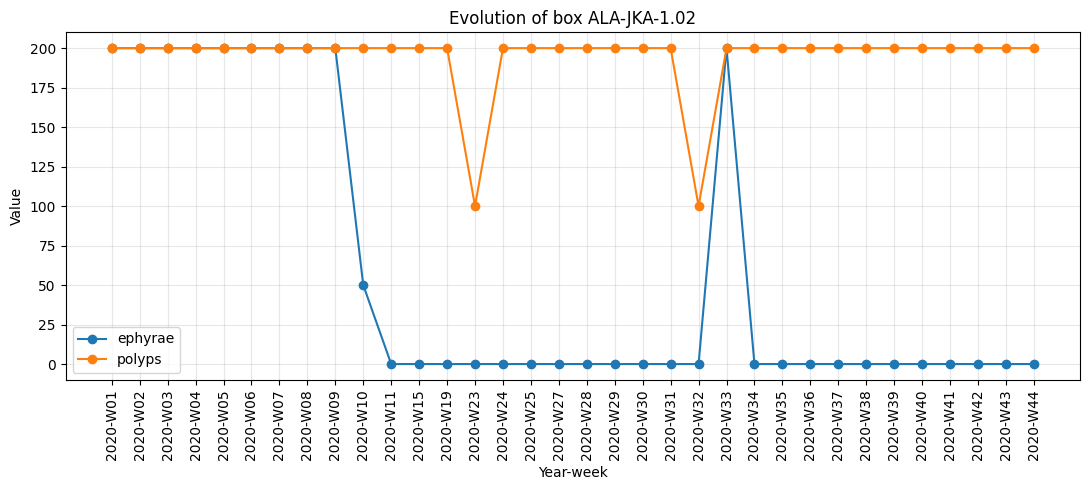

Comment:
This chart helps see whether the box stays stable, produces ephyrae, or has a break in tracking.
This box appears with several temperatures in the data. This may indicate a condition change, but it must be checked in the source file and with the supervisors.
Empty periods are not drawn as zeroes, to avoid creating false drops.


In [11]:
if not entered_values_df.empty:
    # Automatic box choice, editable by hand.
    selected_box = entered_values_df["box"].dropna().iloc[0]

    print("Selected box:", selected_box)
    selected_box_df = entered_values_df[entered_values_df["box"] == selected_box].copy()

    display(selected_box_df[["file_year", "group", "species", "temperature"]].drop_duplicates())

    fig, ax = plt.subplots(figsize=(11, 5))
    for measurement, subgroup_df in selected_box_df.groupby("normalized_measurement_type"):
        subgroup_df = subgroup_df.sort_values(["file_year", "week_index"])
        x_values = subgroup_df["file_year"].astype(str) + "-W" + subgroup_df["week_index"].astype(str).str.zfill(2)
        ax.plot(x_values, subgroup_df["value"], marker="o", label=measurement)

    ax.set_title(f"Evolution of box {selected_box}")
    ax.set_xlabel("Year-week")
    ax.set_ylabel("Value")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

    print("Comment:")
    print("This chart helps see whether the box stays stable, produces ephyrae, or has a break in tracking.")
    if selected_box_df["temperature"].nunique() > 1:
        print("This box appears with several temperatures in the data. This may indicate a condition change, but it must be checked in the source file and with the supervisors.")
    print("Empty periods are not drawn as zeroes, to avoid creating false drops.")
else:
    print("No numeric values available to display the evolution of one box.")


## 12. Détection simple des fortes variations / Simple detection of large variations

**FR -** Ce bloc repère les variations importantes entre deux semaines successives. C'est une aide exploratoire, pas encore une règle métier validée.

**EN -** This block detects large changes between two consecutive weeks. It is an exploratory helper, not a validated business rule yet.


In [12]:
if not entered_values_df.empty:
    variation_df = entered_values_df.sort_values(
        ["box", "file_year", "normalized_measurement_type", "week_index"]
    ).copy()

    variation_df["previous_value"] = (
        variation_df
        .groupby(["box", "file_year", "normalized_measurement_type"])["value"]
        .shift(1)
    )

    variation_df["absolute_change"] = variation_df["value"] - variation_df["previous_value"]
    variation_df["relative_change"] = variation_df["absolute_change"] / variation_df["previous_value"].replace(0, np.nan)

    ABSOLUTE_CHANGE_THRESHOLD = 50
    RELATIVE_CHANGE_THRESHOLD = 0.5

    simple_anomalies = variation_df[
        (variation_df["absolute_change"].abs() >= ABSOLUTE_CHANGE_THRESHOLD) |
        (variation_df["relative_change"].abs() >= RELATIVE_CHANGE_THRESHOLD)
    ].copy()

    display(simple_anomalies.sort_values("absolute_change", key=lambda series: series.abs(), ascending=False).head(50))

    print("Comment:")
    print(f"The table flags changes of at least {ABSOLUTE_CHANGE_THRESHOLD} units or {RELATIVE_CHANGE_THRESHOLD*100:.0f}% from one value to the next.")
    print(f"Flagged changes: {len(simple_anomalies)}.")
    print("These rows are not necessarily errors. They mainly indicate cases to check: ephyrae peak, polyp drop, tracking change, or unusual entry.")
else:
    print("No numeric values available to detect changes.")


,file_year,group,species,box,temperature,measurement_type,normalized_measurement_type,week_index,excel_column,value,previous_value,absolute_change,relative_change
99743,2023,Hydrozoa,Clytia hemisphaerica,CLH-FVI-1.04,15.0,Nb éphyrules,ephyrae,40,44,500.0,3000.0,-2500.0,-0.833333
99589,2023,Hydrozoa,Clytia hemisphaerica,CLH-FVI-1.04,15.0,Nb éphyrules,ephyrae,39,43,3000.0,1000.0,2000.0,2.000000
176699,2025,Hydrozoa,Ectopleura sp.,ECT-JKA-1.01,20.0,Nb éphyrules,ephyrae,45,49,1000.0,0.0,1000.0,NaN
133179,2024,Hydrozoa,Clytia hemisphaerica,CLH-FVI-1.07,15.0,Nb éphyrules,ephyrae,28,32,1000.0,0.0,1000.0,NaN
134069,2024,Hydrozoa,Clytia hemisphaerica,CLH-FVI-1.07,15.0,Nb éphyrules,ephyrae,33,37,1000.0,0.0,1000.0,NaN
176941,2025,Hydrozoa,Ectopleura sp.,ECT-JKA-1.01,20.0,Nb éphyrules,ephyrae,46,50,0.0,1000.0,-1000.0,-1.000000
172939,2025,Hydrozoa,Oceaniidae sp.,OCE-TAI-1.01,25.0,Nb éphyrules,ephyrae,29,33,1000.0,0.0,1000.0,NaN
177397,2025,Hydrozoa,Clytia hemisphaerica,CLH-FVI-1.06,15.0,Nb éphyrules,ephyrae,48,52,1000.0,0.0,1000.0,NaN
96817,2023,Hydrozoa,Clytia hemisphaerica,CLH-FVI-1.04,15.0,Nb éphyrules,ephyrae,21,25,1000.0,0.0,1000.0,NaN
134245,2024,Hydrozoa,Clytia hemisphaerica,CLH-FVI-1.06,15.0,Nb éphyrules,ephyrae,34,38,0.0,1000.0,-1000.0,-1.000000


Comment:
The table flags changes of at least 50 units or 50% from one value to the next.
Flagged changes: 13962.
These rows are not necessarily errors. They mainly indicate cases to check: ephyrae peak, polyp drop, tracking change, or unusual entry.


## 13. Export de la table nettoyée / Exporting the cleaned table

**FR -** La table nettoyée est exportée pour pouvoir être relue, partagée ou utilisée comme base de discussion avec l'équipe.

**EN -** The cleaned table is exported so it can be reviewed, shared, or used as a discussion base with the team.


In [13]:
if not tracking_df.empty:
    OUTPUT_CSV = DATA_DIR / "polyp_tracking_long_format.csv"
    tracking_df.to_csv(OUTPUT_CSV, index=False, encoding="utf-8-sig")

    print("CSV created:", OUTPUT_CSV)
    print("Comment:")
    print("The exported file contains data in long format, which is easier to use in Python, Excel, or a SQL database.")
    print("The utf-8-sig encoding is used to reduce accent issues when opening the file in Excel.")
else:
    print("No data to export.")


CSV created: ..\data\polyp_tracking_long_format.csv
Comment:
The exported file contains data in long format, which is easier to use in Python, Excel, or a SQL database.
The utf-8-sig encoding is used to reduce accent issues when opening the file in Excel.


## 14. Changements de température et repiquages / Temperature changes and repiquage events

**FR -** Ces fichiers complémentaires sont explorés à part, car ils peuvent expliquer certaines ruptures dans les courbes de suivi.

**EN -** These additional files are explored separately because they may explain some breaks in the tracking curves.


In [14]:
if CHANGES_FILE.exists():
    changes_workbook = pd.ExcelFile(CHANGES_FILE)
    print("Sheets found:", changes_workbook.sheet_names)

    for sheet in changes_workbook.sheet_names:
        print()
        print("Sheet:", sheet)
        preview_df = pd.read_excel(CHANGES_FILE, sheet_name=sheet, header=None).head(15)
        display(preview_df)

    print("Comment:")
    print("The file seems organized by year, with species in rows and months in columns.")
    print("The supervisors should confirm whether filled cells mean a subculture event, a temperature change, or another event.")
    print("This file could later be cross-referenced with yearly tracking to better understand empty periods or temperature changes.")
else:
    print("File not found:", CHANGES_FILE)


Sheets found: ['2022', '2023', '2024']

Sheet: 2022


,0,1,2,3,4,5,6,7,8,9,10,11,12
0,Planning repiquage de nouvelles boîtes et chan...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,Année : 2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,J,F,M,A,M,J,J,A,S,O,N,D
5,Aequorea coerulescens,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Aequorea victoria,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Alatina morandini,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,Aurelia labiata,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,Aurelia limbata,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Sheet: 2023


,0,1,2,3,4,5,6,7,8,9,10,11,12
0,Planning repiquage de nouvelles boîtes et chan...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,Année : 2023,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,J,F,M,A,M,J,J,A,S,O,N,D
5,Aequorea coerulescens,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Aequorea macrodactyla,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Aequorea victoria,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,Alatina morandini,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,Aurelia labiata,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Sheet: 2024


,0,1,2,3,4,5,6,7,8,9,10,11,12
0,Planning repiquage de nouvelles boîtes et chan...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,Année 2024,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,J,F,M,A,M,J,J,A,S,O,N,D
5,Aequorea coerulescens,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Aequorea macrodactyla,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Aequorea victoria,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,Alatina morandini,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,Aurelia coerulea,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Comment:
The file seems organized by year, with species in rows and months in columns.
The supervisors should confirm whether filled cells mean a subculture event, a temperature change, or another event.
This file could later be cross-referenced with yearly tracking to better understand empty periods or temperature changes.


## 15. Fichier de strobilation / Strobilation file

**FR -** Ce fichier est inspecté pour comprendre s'il doit devenir une table spécifique dans la future base de données.

**EN -** This file is inspected to understand whether it should become a dedicated table in the future database.


In [15]:
if STROBILATION_FILE.exists():
    strobilation_workbook = pd.ExcelFile(STROBILATION_FILE)
    print("Sheets found:", strobilation_workbook.sheet_names)

    strobilation_df = pd.read_excel(STROBILATION_FILE, sheet_name=strobilation_workbook.sheet_names[0], header=None)
    display(strobilation_df.head(30))

    print("Comment:")
    print("The file contains species and several possible strobilation conditions, such as temperature, salinity, light, or specific substances.")
    print("The preview looks incomplete. The exact meaning of the columns should be checked before calculating statistics.")
else:
    print("File not found:", STROBILATION_FILE)


Sheets found: ['Feuil1', 'Feuil2', 'Feuil3']


,0,1,2,3,4,5,6
0,NaN,Nombre de jours pour la strobilation,NaN,NaN,NaN,NaN,NaN
1,Espèce,Température,Salinité,Lumière,Indométacine,2-méthyl-indole,Lugol
2,Aequorea coerulescens,NaN,NaN,NaN,NaN,NaN,NaN
3,Aequorea victoria,NaN,NaN,NaN,NaN,NaN,NaN
4,Aurelia aurita,NaN,NaN,NaN,NaN,NaN,NaN
5,Aurelia labiata,NaN,NaN,NaN,NaN,NaN,NaN
6,Aurelia limbata,NaN,NaN,NaN,NaN,NaN,NaN
7,Aurelia maldivensis,NaN,NaN,NaN,NaN,NaN,NaN
8,Carybdea marsupialis,NaN,NaN,NaN,NaN,NaN,NaN
9,Carybdea morandinii,NaN,NaN,NaN,NaN,NaN,NaN


Comment:
The file contains species and several possible strobilation conditions, such as temperature, salinity, light, or specific substances.
The preview looks incomplete. The exact meaning of the columns should be checked before calculating statistics.


## 16. Conclusion provisoire / Preliminary conclusion

**FR -** Cette première analyse montre que les fichiers Excel peuvent être transformés en une table commune exploitable pour Polypbase. Le format long semble adapté pour stocker les observations, filtrer par année, espèce, boîte et température, puis construire des exports propres.

**EN -** This first analysis shows that the Excel files can be reshaped into one common table usable by Polypbase. The long format seems appropriate for storing observations, filtering by year, species, box, and temperature, and building clean exports.

**FR - Points à clarifier :** le sens exact des cellules vides, la gestion des repiquages, les changements de température, les noms de groupes et la différence entre température Excel, zone thermique et mesure de sonde.

**EN - Points to clarify:** the exact meaning of empty cells, how to model repiquage events, temperature changes, group names, and the difference between Excel temperature, thermal zone, and probe measurement.
